<a href="https://colab.research.google.com/github/Roberto-Lecher/Analise-de-dados-com-Google-Colab/blob/main/Freq_de_Vendas%C2%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Distribuição dos fits:
fit_ideal
Baggy      502
Regular    443
Skinny     388
Relaxed    351
Slim       316
Name: count, dtype: int64

Primeiras linhas:
   cintura_cm  quadril_cm  comprimento_perna_cm   altura_cm    peso_kg  idade  \
0   90.960570   91.248217             81.092051  158.859186  69.504621     59   
1   83.340828   96.554813             87.750372  163.690692  62.445246     34   
2   92.772262   90.075801             88.144135  160.579398  67.414376     48   
3  103.276358   94.920385             91.781043  164.520042  80.720976     51   
4   82.190160   79.063853             77.065133  167.858497  89.167850     55   

  fit_ideal lavagem_preferida faixa_preco  
0     Baggy         Raw Denim   Econômico  
1   Regular         Dark Wash      Padrão  
2     Baggy         Raw Denim   Econômico  
3     Baggy        Light Wash        Luxo  
4     Baggy        Light Wash   Econômico  

Relatório de Classificação:
              precision    recall  f1-score   support

       Baggy

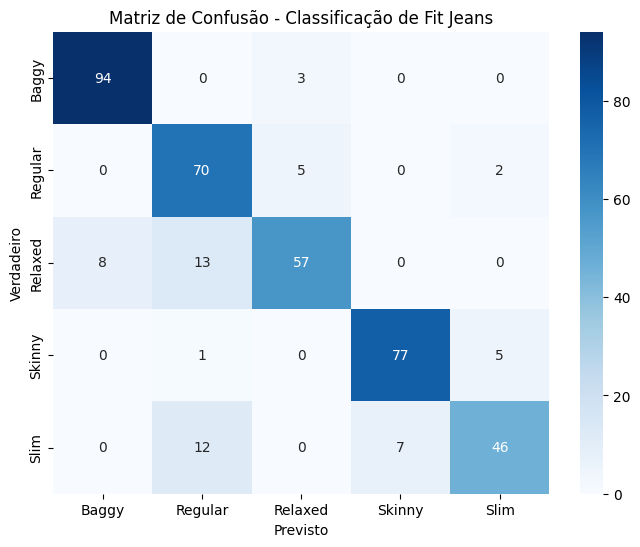

Catálogo de Jeans:
           modelo       fit  preco  elasticidade  popularidade
0      Skinny 001    Skinny  129.9             2            81
1        Slim 002      Slim  149.9             3            86
2     Regular 003   Regular  159.9             5            71
3     Relaxed 004   Relaxed  179.9             7            10
4       Baggy 005     Baggy  199.9             8            93
5  Slim Taper 006      Slim  169.9             4            36
6     Bootcut 007   Relaxed  159.9             3            24
7    Straight 008   Regular  149.9             5            64
8    Athletic 009  Athletic  189.9             6            56

SISTEMA DE RECOMENDAÇÃO DE JEANS

👖 Para suas medidas (cintura 82cm, quadril 96cm):
✅ Fit recomendado: Regular

📋 Modelos sugeridos:
      modelo     fit  preco  elasticidade  popularidade
 Regular 003 Regular  159.9             5            71
Straight 008 Regular  149.9             5            64

📊 PREVISÃO DE VENDAS
MAE: R$115.55
R² Score: -0.

/tmp/ipykernel_503/1348493184.py:173: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  meses = pd.date_range('2023-01-01', periods=24, freq='M')


  Baggy 005 - Feb/2025: 1008 unidades
  Baggy 005 - Mar/2025: 1041 unidades


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128086 (\N{JEANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


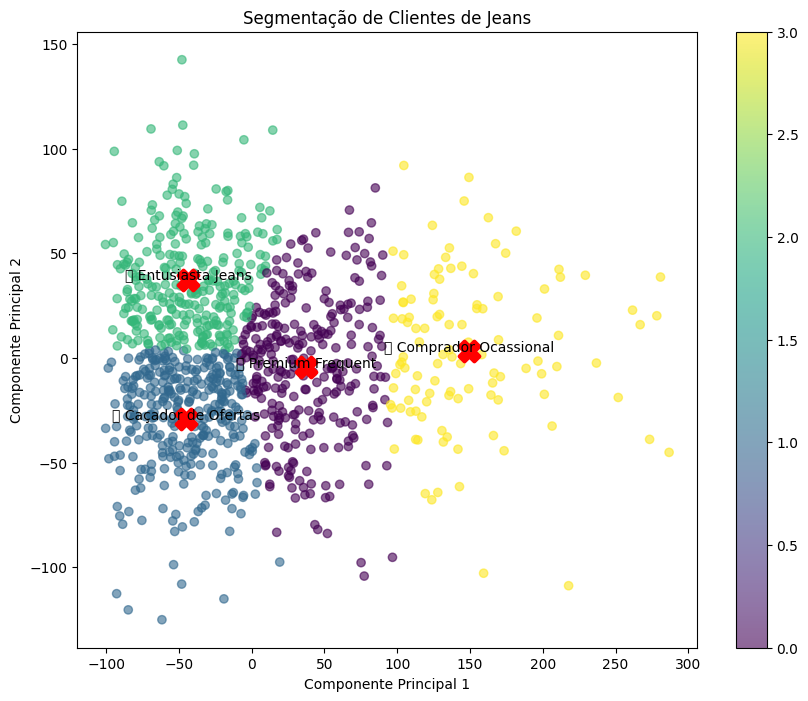


📊 Perfil dos segmentos:
                        gasto_medio_mensal  frequencia_compras  \
segmento_nome                                                    
🆕 Comprador Ocassional              252.54                1.98   
👑 Premium Frequent                  140.51                1.96   
👖 Entusiasta Jeans                   59.89                2.06   
💸 Caçador de Ofertas                 57.23                2.00   

                        nr_jeans_possui  valor_medio_jeans  
segmento_nome                                               
🆕 Comprador Ocassional             3.97             150.49  
👑 Premium Frequent                 4.01             143.91  
👖 Entusiasta Jeans                 3.86             186.69  
💸 Caçador de Ofertas               4.02             120.06  


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Criar dataset sintético de clientes e seus fits preferidos
np.random.seed(42)
n_clientes = 2000

# Características dos clientes
dados = {
    'cintura_cm': np.random.normal(85, 12, n_clientes),  # média 85cm
    'quadril_cm': np.random.normal(98, 10, n_clientes),   # média 98cm
    'comprimento_perna_cm': np.random.normal(88, 8, n_clientes),
    'altura_cm': np.random.normal(170, 10, n_clientes),
    'peso_kg': np.random.normal(70, 15, n_clientes),
    'idade': np.random.randint(18, 60, n_clientes)
}

df = pd.DataFrame(dados)



# Criar regras para determinar o fit ideal
def determinar_fit(row):
    relacao_cintura_quadril = row['cintura_cm'] / row['quadril_cm']

    if relacao_cintura_quadril < 0.75:
        return 'Skinny'  # muito magro
    elif relacao_cintura_quadril < 0.82:
        return 'Slim'
    elif relacao_cintura_quadril < 0.90:
        return 'Regular'
    elif relacao_cintura_quadril < 0.98:
        return 'Relaxed'
    else:
        return 'Baggy'

df['fit_ideal'] = df.apply(determinar_fit, axis=1)

# Adicionar preferências de lavagem e preço
lavagens = ['Stone Wash', 'Dark Wash', 'Light Wash', 'Raw Denim', 'Destroyed']
precos = ['Econômico', 'Padrão', 'Premium', 'Luxo']

df['lavagem_preferida'] = np.random.choice(lavagens, n_clientes)
df['faixa_preco'] = np.random.choice(precos, n_clientes, p=[0.4, 0.35, 0.15, 0.1])

print("Distribuição dos fits:")
print(df['fit_ideal'].value_counts())
print("\nPrimeiras linhas:")
print(df.head())

# Preparar dados para ML
# Codificar variáveis categóricas
le_lavagem = LabelEncoder()
le_preco = LabelEncoder()
le_fit = LabelEncoder()

df['lavagem_cod'] = le_lavagem.fit_transform(df['lavagem_preferida'])
df['preco_cod'] = le_preco.fit_transform(df['faixa_preco'])
df['fit_cod'] = le_fit.fit_transform(df['fit_ideal'])

# Features e target
feature_cols = ['cintura_cm', 'quadril_cm', 'comprimento_perna_cm',
                'altura_cm', 'peso_kg', 'idade', 'lavagem_cod', 'preco_cod']
X = df[feature_cols]
y = df['fit_cod']

# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar features numéricas
scaler = StandardScaler()
numeric_cols = ['cintura_cm', 'quadril_cm', 'comprimento_perna_cm', 'altura_cm', 'peso_kg', 'idade']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Treinar modelo
modelo_fit = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
modelo_fit.fit(X_train, y_train)

# Avaliar
y_pred = modelo_fit.predict(X_test)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le_fit.classes_))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_fit.classes_,
            yticklabels=le_fit.classes_)
plt.title('Matriz de Confusão - Classificação de Fit Jeans')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

# Criar catálogo de jeans
catalogo_jeans = pd.DataFrame({
    'modelo': ['Skinny 001', 'Slim 002', 'Regular 003', 'Relaxed 004', 'Baggy 005',
               'Slim Taper 006', 'Bootcut 007', 'Straight 008', 'Athletic 009'],
    'fit': ['Skinny', 'Slim', 'Regular', 'Relaxed', 'Baggy',
            'Slim', 'Relaxed', 'Regular', 'Athletic'],
    'preco': [129.90, 149.90, 159.90, 179.90, 199.90,
              169.90, 159.90, 149.90, 189.90],
    'elasticidade': [2, 3, 5, 7, 8, 4, 3, 5, 6],  # 1-10 (mais = mais elástico)
    'popularidade': np.random.randint(1, 100, 9)
})

print("Catálogo de Jeans:")
print(catalogo_jeans)

# Função de recomendação
def recomendar_jeans(cintura, quadril, comprimento_perna, altura, peso, idade,
                     preferencia_lavagem='Dark Wash', orcamento_max=200):

    # Criar dataframe do cliente
    cliente = pd.DataFrame({
        'cintura_cm': [cintura],
        'quadril_cm': [quadril],
        'comprimento_perna_cm': [comprimento_perna],
        'altura_cm': [altura],
        'peso_kg': [peso],
        'idade': [idade],
        'lavagem_cod': [le_lavagem.transform([preferencia_lavagem])[0]],
        'preco_cod': [le_preco.transform(['Padrão'])[0]]  # placeholder
    })

    # Escalar features numéricas
    cliente[numeric_cols] = scaler.transform(cliente[numeric_cols])

    # Prever fit ideal
    fit_predito_cod = modelo_fit.predict(cliente)[0]
    fit_predito = le_fit.inverse_transform([fit_predito_cod])[0]

    # Filtrar catálogo por fit e orçamento
    recomendacoes = catalogo_jeans[
        (catalogo_jeans['fit'] == fit_predito) &
        (catalogo_jeans['preco'] <= orcamento_max)
    ].sort_values('popularidade', ascending=False)

    return fit_predito, recomendacoes

# Testar recomendação
print("\n" + "="*50)
print("SISTEMA DE RECOMENDAÇÃO DE JEANS")
print("="*50)

cintura = 82
quadril = 96
comprimento = 85
altura = 175
peso = 72
idade = 28

fit_sugerido, opcoes = recomendar_jeans(cintura, quadril, comprimento, altura,
                                         peso, idade, 'Dark Wash', 180)

print(f"\n👖 Para suas medidas (cintura {cintura}cm, quadril {quadril}cm):")
print(f"✅ Fit recomendado: {fit_sugerido}")
print("\n📋 Modelos sugeridos:")
print(opcoes[['modelo', 'fit', 'preco', 'elasticidade', 'popularidade']].to_string(index=False))

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Criar dados históricos de vendas
np.random.seed(42)
meses = pd.date_range('2023-01-01', periods=24, freq='M')
modelos = catalogo_jeans['modelo'].tolist()

dados_vendas = []
for modelo in modelos:
    for mes in meses:
        # Fatores que afetam vendas
        temporada = 1.5 if mes.month in [11, 12] else 1.0  # Natal
        tendencia = 1 + (mes - meses[0]).days / 365 * 0.1  # crescimento anual

        base_vendas = np.random.normal(500, 100)
        vendas = base_vendas * temporada * tendencia

        dados_vendas.append({
            'mes': mes,
            'modelo': modelo,
            'preco': catalogo_jeans[catalogo_jeans['modelo'] == modelo]['preco'].values[0],
            'elasticidade': catalogo_jeans[catalogo_jeans['modelo'] == modelo]['elasticidade'].values[0],
            'vendas': int(vendas)
        })

df_vendas = pd.DataFrame(dados_vendas)

# Preparar features para previsão
df_vendas['mes_num'] = df_vendas['mes'].dt.month
df_vendas['tendencia'] = range(len(df_vendas))

# One-hot encoding para modelo
df_vendas = pd.get_dummies(df_vendas, columns=['modelo'], prefix='mod')

# Treinar modelo de previsão
features_previsao = ['preco', 'elasticidade', 'mes_num', 'tendencia'] + \
                    [col for col in df_vendas.columns if col.startswith('mod_')]
X_vendas = df_vendas[features_previsao]
y_vendas = df_vendas['vendas']

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vendas, y_vendas,
                                                              test_size=0.2, random_state=42)

modelo_vendas = LinearRegression()
modelo_vendas.fit(X_train_v, y_train_v)

# Avaliar
y_pred_v = modelo_vendas.predict(X_test_v)
print("\n📊 PREVISÃO DE VENDAS")
print(f"MAE: R${mean_absolute_error(y_test_v, y_pred_v):.2f}")
print(f"R² Score: {r2_score(y_test_v, y_pred_v):.3f}")

# Prever vendas próximos 3 meses
print("\n🔮 Previsão para próximos meses:")
for modelo in ['Slim 002', 'Regular 003', 'Baggy 005']:
    ultimo_mes = df_vendas['mes'].max()
    for i in range(1, 4):
        nova_previsao = pd.DataFrame({
            'preco': [catalogo_jeans[catalogo_jeans['modelo'] == modelo]['preco'].values[0]],
            'elasticidade': [catalogo_jeans[catalogo_jeans['modelo'] == modelo]['elasticidade'].values[0]],
            'mes_num': [(ultimo_mes + pd.DateOffset(months=i)).month],
            'tendencia': [len(df_vendas) + i]
        })

        # Adicionar colunas dummy
        for col in [c for c in features_previsao if c.startswith('mod_')]:
            nova_previsao[col] = 1 if col == f'mod_{modelo}' else 0

        vendas_pred = modelo_vendas.predict(nova_previsao[features_previsao])[0]
        print(f"  {modelo} - {ultimo_mes + pd.DateOffset(months=i):%b/%Y}: {vendas_pred:.0f} unidades")

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Criar perfil de clientes para segmentação
np.random.seed(42)
n_clientes_seg = 1000

df_clientes = pd.DataFrame({
    'gasto_medio_mensal': np.random.gamma(2, 50, n_clientes_seg),
    'frequencia_compras': np.random.poisson(2, n_clientes_seg),
    'tempo_site_min': np.random.exponential(5, n_clientes_seg),
    'nr_jeans_possui': np.random.poisson(4, n_clientes_seg),
    'valor_medio_jeans': np.random.normal(150, 40, n_clientes_seg)
})

# Aplicar segmentação
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clientes['segmento'] = kmeans.fit_predict(df_clientes)

# Nomear segmentos
segmentos_nomes = {
    0: '👑 Premium Frequent',
    1: '💸 Caçador de Ofertas',
    2: '👖 Entusiasta Jeans',
    3: '🆕 Comprador Ocassional'
}

df_clientes['segmento_nome'] = df_clientes['segmento'].map(segmentos_nomes)

# Visualizar segmentos com PCA
pca = PCA(n_components=2)
componentes = pca.fit_transform(df_clientes.drop(['segmento', 'segmento_nome'], axis=1))

plt.figure(figsize=(10, 8))
scatter = plt.scatter(componentes[:, 0], componentes[:, 1],
                      c=df_clientes['segmento'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title('Segmentação de Clientes de Jeans')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Adicionar centróides
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            c='red', marker='X', s=200, linewidths=3)

# Anotar segmentos
for i, txt in enumerate(segmentos_nomes.values()):
    plt.annotate(txt, (centroides_pca[i, 0], centroides_pca[i, 1]),
                fontsize=10, ha='center')

plt.show()

print("\n📊 Perfil dos segmentos:")
segmento_perfil = df_clientes.groupby('segmento_nome').agg({
    'gasto_medio_mensal': 'mean',
    'frequencia_compras': 'mean',
    'nr_jeans_possui': 'mean',
    'valor_medio_jeans': 'mean'
}).round(2)

print(segmento_perfil)